In [7]:
# =====================================================================
# SEL 1: IMPORT & SETUP ENVIRONMENT
# =====================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import joblib

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Konfigurasi MLflow
mlflow_tracking_uri = r"file:///D:/LENTERA_LAUT/mlruns"
mlflow.set_tracking_uri(mlflow_tracking_uri)
print(f"📁 MLflow Tracking URI: {mlflow_tracking_uri}")

# Konfigurasi Visualisasi
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

# Memuat Dataset
file_path = r"D:\LENTERA_LAUT\data\processed\final_dataset.csv"
df = pd.read_csv(file_path)

features = [
    "wave_height", "wind_speed_10m", "ocean_current_velocity", 
    "sea_surface_temperature", "precipitation", "visibility"
]
base_df = df.drop(columns=["time", "location", "id_location"], errors='ignore')

print(f"✅ Data siap: {len(base_df)} baris.")

📁 MLflow Tracking URI: file:///D:/LENTERA_LAUT/mlruns
✅ Data siap: 13026 baris.


In [8]:
# =====================================================================
# SEL 2: FUNGSI PEMBUATAN LEARNING CURVE
# =====================================================================
def plot_learning_curve(estimator, title, X, y, cv=3, n_jobs=-1):
    plt.figure(figsize=(8, 5))
    plt.title(f"Learning Curve (Baseline) - {title}", fontsize=14, pad=15, fontweight='bold')
    plt.xlabel("Jumlah Data Pelatihan", fontsize=12)
    plt.ylabel("RMSE", fontsize=12)
    
    # Kalkulasi Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='neg_root_mean_squared_error'
    )
    
    # Konversi ke nilai positif (RMSE)
    train_scores_mean = -np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot Training
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="#F0AD4E")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="#F0AD4E", label="Training Error")
    
    # Plot Validation
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#4A7c59")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="#4A7c59", label="Validation Error")
    
    plt.legend(loc="best")
    plt.tight_layout()
    
    # Simpan plot ke disk
    reports_dir = r"D:\LENTERA_LAUT\reports\figures"
    os.makedirs(reports_dir, exist_ok=True)
    plot_path = os.path.join(reports_dir, f"lc_baseline_{title}.png")
    plt.savefig(plot_path, dpi=300)
    plt.close()
    
    return plot_path

print("✅ Fungsi Learning Curve siap digunakan.")

✅ Fungsi Learning Curve siap digunakan.


In [9]:
# =====================================================================
# SEL 3: MANUAL BASELINE MODELING & EXPORT
# =====================================================================
# Kandidat model berdasarkan hasil observasi PyCaret sebelumnya
manual_models = {
    "LinearRegression": LinearRegression(),
    "ExtraTrees": ExtraTreesRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0)
}

models_dir = r"D:\LENTERA_LAUT\models\baseline_models"
os.makedirs(models_dir, exist_ok=True)

for target in features:
    print(f"\n{'='*40}")
    print(f"🎯 FOKUS TARGET: {target.upper()}")
    
    # Cegah Data Leakage
    other_targets = [col for col in features if col != target]
    X = base_df.drop(columns=other_targets + [target], errors='ignore')
    y = base_df[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Set Eksperimen di MLflow
    mlflow.set_experiment(f"Manual_Baseline_{target}")
    
    best_name = ""
    best_rmse = float('inf')
    best_model = None
    
    print("   -> Mengevaluasi kandidat model...")
    for name, model in manual_models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        
        if rmse < best_rmse:
            best_rmse = rmse
            best_name = name
            best_model = model
            
    print(f"🏆 Pemenang Baseline: {best_name} (RMSE: {best_rmse:.4f})")
    
    # Catat sang pemenang ke MLflow
    with mlflow.start_run(run_name=f"Baseline_{best_name}_{target}"):
        
        # Buat Learning Curve dari model pemenang menggunakan X_train
        print(f"   -> Membuat grafik Learning Curve untuk {best_name}...")
        plot_path = plot_learning_curve(best_model, f"{best_name}_{target}", X_train, y_train)
        
        # Hitung R2 Score
        final_preds = best_model.predict(X_test)
        final_r2 = r2_score(y_test, final_preds)
        
        # Logging ke MLflow
        mlflow.log_param("Model_Type", best_name)
        mlflow.log_metric("Baseline_RMSE", best_rmse)
        mlflow.log_metric("Baseline_R2", final_r2)
        mlflow.log_artifact(plot_path) # Simpan gambar grafik
        
        # Export Model Baseline untuk dituning di file terpisah
        model_filename = os.path.join(models_dir, f"baseline_model_{target}.pkl")
        joblib.dump(best_model, model_filename)
        
        print(f"✅ Grafik dan metrik dicatat di MLflow.")
        print(f"✅ Model mentah diekspor ke: {model_filename}")

print("\n🎉 FASE MANUAL MODELING SELESAI!")

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/28 10:02:19 INFO mlflow.tracking.fluent: Experiment with name 'Manual_Baseline_wave_height' does not exist. Creating a new experiment.



🎯 FOKUS TARGET: WAVE_HEIGHT
   -> Mengevaluasi kandidat model...


C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
 

🏆 Pemenang Baseline: LinearRegression (RMSE: 0.0134)
   -> Membuat grafik Learning Curve untuk LinearRegression...


2026/05/28 10:02:33 INFO mlflow.tracking.fluent: Experiment with name 'Manual_Baseline_wind_speed_10m' does not exist. Creating a new experiment.


...

✅ Grafik dan metrik dicatat di MLflow.
✅ Model mentah diekspor ke: D:\LENTERA_LAUT\models\baseline_models\baseline_model_ocean_current_velocity.pkl

🎯 FOKUS TARGET: SEA_SURFACE_TEMPERATURE
   -> Mengevaluasi kandidat model...
🏆 Pemenang Baseline: ExtraTrees (RMSE: 0.0488)
   -> Membuat grafik Learning Curve untuk ExtraTrees...


2026/05/28 10:03:24 INFO mlflow.tracking.fluent: Experiment with name 'Manual_Baseline_precipitation' does not exist. Creating a new experiment.


✅ Grafik dan metrik dicatat di MLflow.
✅ Model mentah diekspor ke: D:\LENTERA_LAUT\models\baseline_models\baseline_model_sea_surface_temperature.pkl

🎯 FOKUS TARGET: PRECIPITATION
   -> Mengevaluasi kandidat model...
🏆 Pemenang Baseline: RandomForest (RMSE: 0.2219)
   -> Membuat grafik Learning Curve untuk RandomForest...


2026/05/28 10:03:45 INFO mlflow.tracking.fluent: Experiment with name 'Manual_Baseline_visibility' does not exist. Creating a new experiment.


✅ Grafik dan metrik dicatat di MLflow.
✅ Model mentah diekspor ke: D:\LENTERA_LAUT\models\baseline_models\baseline_model_precipitation.pkl

🎯 FOKUS TARGET: VISIBILITY
   -> Mengevaluasi kandidat model...
🏆 Pemenang Baseline: LightGBM (RMSE: 6317.8352)
   -> Membuat grafik Learning Curve untuk LightGBM...
✅ Grafik dan metrik dicatat di MLflow.
✅ Model mentah diekspor ke: D:\LENTERA_LAUT\models\baseline_models\baseline_model_visibility.pkl

🎉 FASE MANUAL MODELING SELESAI!


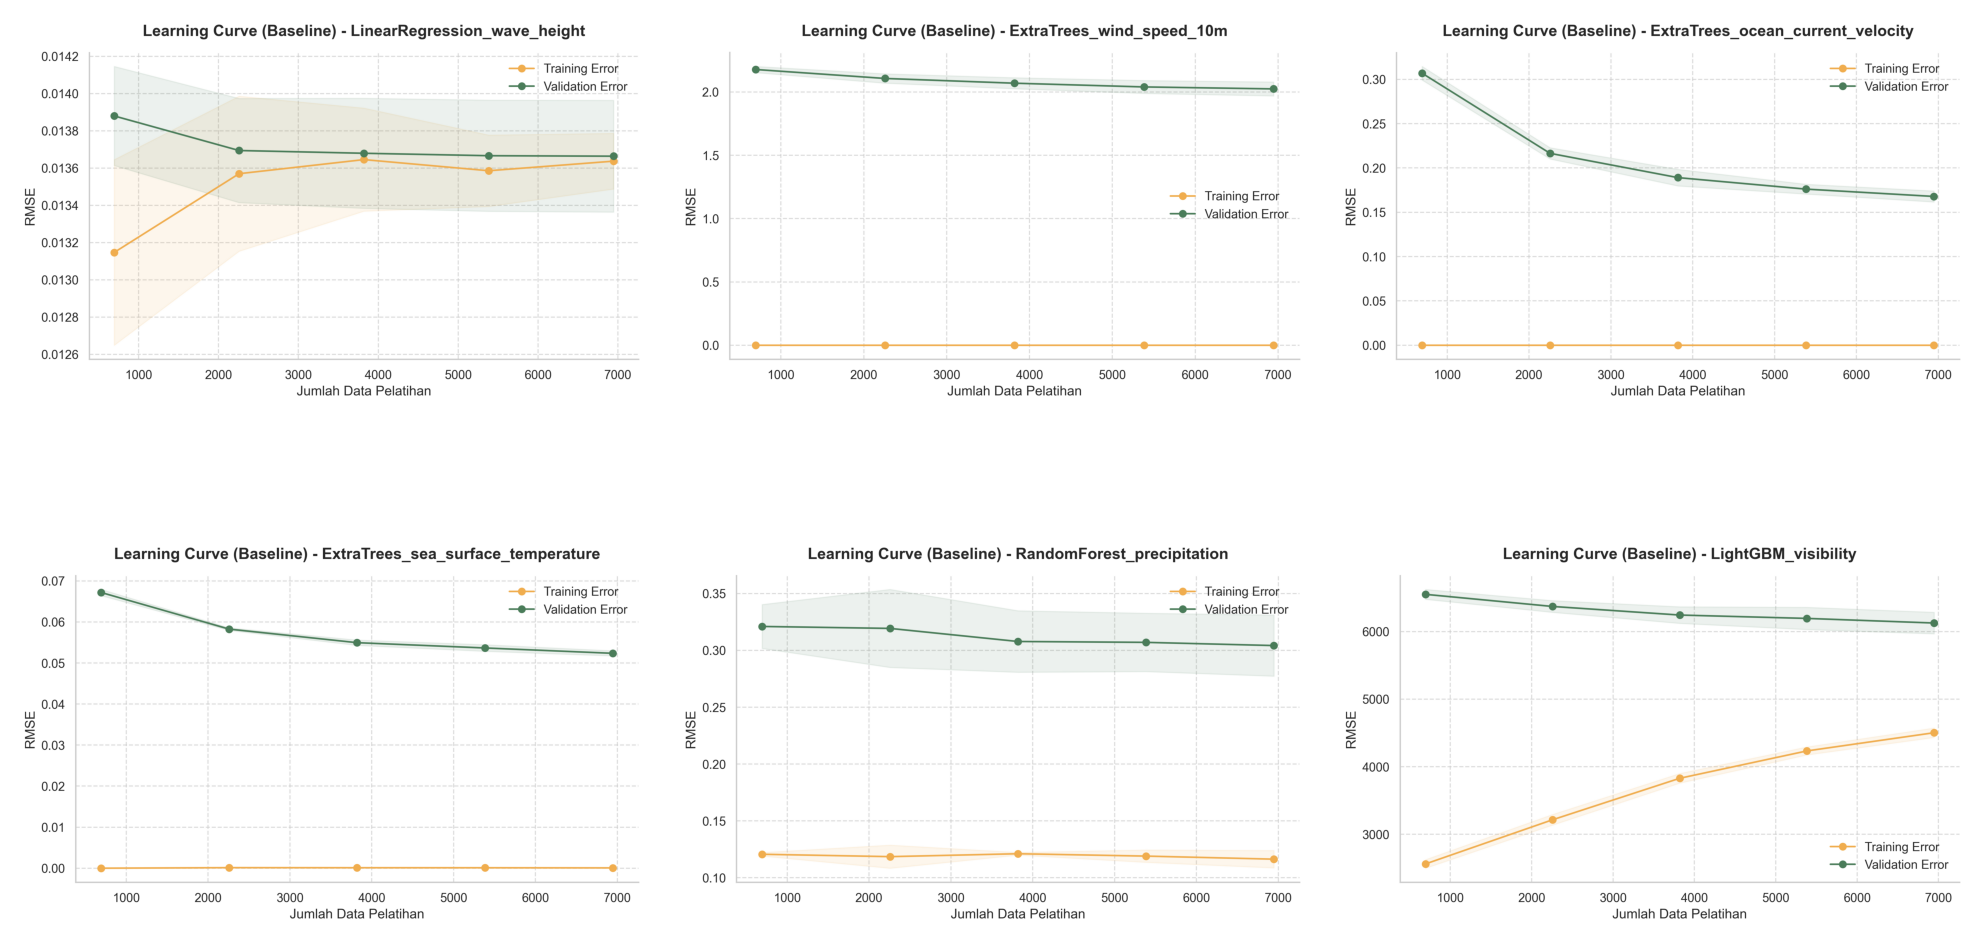

In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Pemetaan target dengan algoritma pemenang sesuai dengan log eksekusi terminalmu
best_models_map = {
    "wave_height": "LinearRegression",
    "wind_speed_10m": "ExtraTrees",
    "ocean_current_velocity": "ExtraTrees",
    "sea_surface_temperature": "ExtraTrees",
    "precipitation": "RandomForest",
    "visibility": "LightGBM"
}

# Direktori tempat gambar disimpan (Absolute Path)
figures_dir = r"D:\LENTERA_LAUT\reports\figures"

# Membuat kanvas (figure) besar untuk menampung 6 gambar sekaligus
plt.figure(figsize=(20, 12))

# Looping untuk menampilkan setiap gambar dalam format grid 2 baris, 3 kolom
for i, (target, model_name) in enumerate(best_models_map.items(), 1):
    file_name = f"lc_baseline_{model_name}_{target}.png"
    file_path = os.path.join(figures_dir, file_name)
    
    plt.subplot(2, 3, i)
    if os.path.exists(file_path):
        img = mpimg.imread(file_path)
        plt.imshow(img)
        plt.axis('off') # Sembunyikan garis tepi bawaan kanvas karena gambar sudah punya garis sendiri
    else:
        plt.text(0.5, 0.5, f"❌ Gambar tidak ditemukan:\n{file_name}", 
                 ha='center', va='center', fontsize=12, color='red')
        plt.axis('off')

plt.tight_layout()
plt.show()